<a href="https://colab.research.google.com/github/srinath698/Automated-ticket-classifier/blob/main/notebooks/01_EDA_Support_Tickets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split



In [1]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss
)

import joblib

In [3]:
df=pd.read_csv('/content/support_tickets.csv')

In [4]:
df.head()

,text,label
0,Subscription not renewing properly.,billing_issue
1,Two-factor auth broken.,account_problem
2,How do I PDF?,general_inquiry
3,No receipt after purchase.,billing_issue
4,Can we add support for search?,feature_request


In [5]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1juZaJK5ymb3slMBANhIf5sFDWF-wkOdkG54CK9Ah2rU/edit#gid=0


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2000
Number of columns: 2


In [7]:
df.sample(10, random_state=42)

,text,label
1860,Is web available?,general_inquiry
353,Recommended setup for Feb.,general_inquiry
1333,Demo request.,general_inquiry
905,Privacy policy question.,general_inquiry
1289,Multi-language support for new@example.com?,feature_request
1273,Subscription not renewing properly.,billing_issue
938,Add integration with save.,feature_request
1731,No receipt after purchase.,billing_issue
65,Payment not recognized for old@example.com.,billing_issue
1323,How do I $10?,general_inquiry


In [9]:
print("Columns in dataset:")
print(df.columns.tolist())
df.dtypes

Columns in dataset:
['text', 'label']


,0
text,object
label,object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2000 non-null   object
 1   label   2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [11]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
text     0
label    0
dtype: int64


In [12]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
text     0.0
label    0.0
dtype: float64


In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1174


In [14]:
duplicate_text_count = df["text"].duplicated().sum()

print("Duplicate ticket texts:", duplicate_text_count)

Duplicate ticket texts: 1174


In [15]:
empty_tickets = df["text"].fillna("").str.strip().eq("").sum()

print("Empty ticket texts:", empty_tickets)

Empty ticket texts: 0


In [19]:
print("Number of categories:", df["label"].nunique())
print("Categories:")
print(df["label"].unique())
category_counts = df["label"].value_counts()

print(category_counts)
category_percentage = df["label"].value_counts(normalize=True) * 100

print(category_percentage.round(2))


Number of categories: 5
Categories:
['billing_issue' 'account_problem' 'general_inquiry' 'feature_request'
 'bug']
label
billing_issue      400
account_problem    400
general_inquiry    400
feature_request    400
bug                400
Name: count, dtype: int64
label
billing_issue      20.0
account_problem    20.0
general_inquiry    20.0
feature_request    20.0
bug                20.0
Name: proportion, dtype: float64


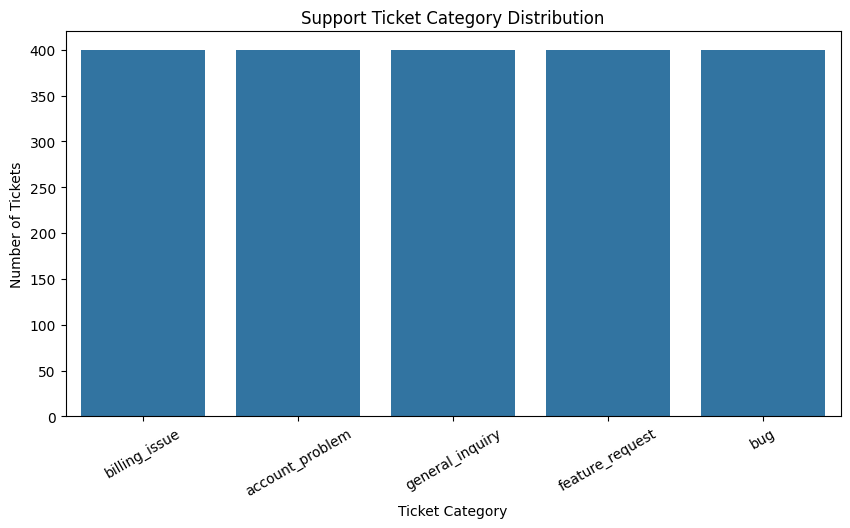

In [20]:
plt.figure(figsize=(10, 5))

sns.countplot(data=df, x="label")

plt.title("Support Ticket Category Distribution")
plt.xlabel("Ticket Category")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=30)

plt.show()

In [21]:
df["text_length"] = df["text"].fillna("").str.len()

df["text_length"].describe()

,text_length
count,2000.000000
mean,29.074000
std,6.563845
min,13.000000
25%,25.000000
50%,28.000000
75%,34.000000
max,53.000000


In [23]:
df.nsmallest(10, "word_count")[["text", "label", "word_count"]]
df.nlargest(10, "word_count")[["text", "label", "word_count"]]

,text,label,word_count
291,UI is broken on query test. Can you fix?,bug,9
899,UI is broken on query test. Can you fix?,bug,9
14,UI is broken on Google. Can you fix?,bug,8
18,UI is broken on email. Can you fix?,bug,8
27,The app crashes when I try to PDF.,bug,8
47,The app crashes when I try to Jan.,bug,8
82,The app crashes when I try to new@example.com.,bug,8
129,UI is broken on login. Can you fix?,bug,8
163,The app crashes when I try to 67890.,bug,8
168,The app crashes when I try to save.,bug,8


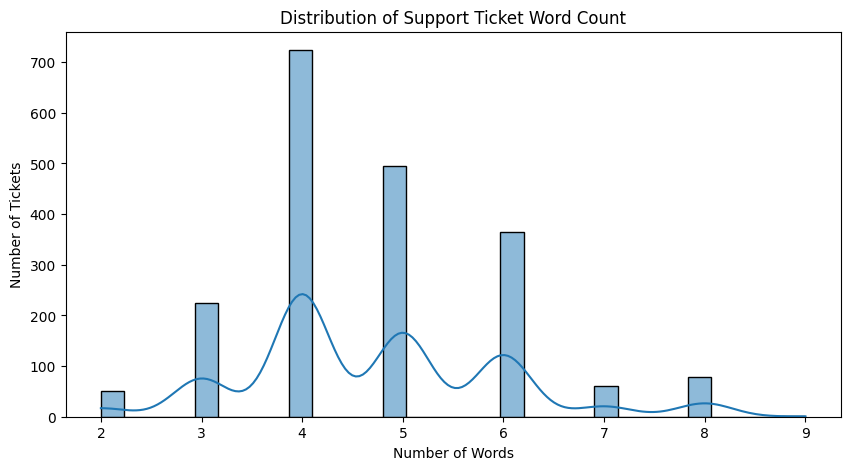

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(df["word_count"], bins=30, kde=True)

plt.title("Distribution of Support Ticket Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Number of Tickets")

plt.show()

In [25]:
from collections import Counter
import re

all_words = []

for text in df["text"].fillna(""):
    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    all_words.extend(words)

word_counts = Counter(all_words)

print("Most common words:")
print(word_counts.most_common(20))

Most common words:
[('for', 428), ('to', 270), ('not', 264), ('on', 207), ('login', 161), ('is', 152), ('please', 150), ('add', 123), ('error', 123), ('my', 114), ('in', 113), ('app', 110), ('profile', 106), ('old', 104), ('request', 100), ('export', 99), ('with', 98), ('after', 94), ('properly', 93), ('example', 93)]


In [26]:
for category in df["label"].unique():
    print("\n" + "=" * 60)
    print("CATEGORY:", category)
    print("=" * 60)

    samples = df[df["label"] == category]["text"].sample(
        min(5, len(df[df["label"] == category])),
        random_state=42
    )

    for ticket in samples:
        print("-", ticket)


CATEGORY: billing_issue
- Dispute charge of 404.
- Dispute charge of save.
- Subscription not renewing properly.
- Payment not recognized for email.
- Charged twice for Jan. Refund?

CATEGORY: account_problem
- Cannot login: invalid credentials.
- Forgot password, reset not working.
- Two-factor auth broken.
- Access denied to 500.
- Forgot password, reset not working.

CATEGORY: general_inquiry
- Status of my ticket web.
- Contact sales for enterprise.
- Where to find export?
- Privacy policy question.
- Privacy policy question.

CATEGORY: feature_request
- Please add export to query test.
- Shortcut keys for 500.
- Shortcut keys for Android.
- Need option to login in bulk.
- Shortcut keys for login.

CATEGORY: bug
- $20 button does nothing.
- Data not saving properly after users.
- The app crashes when I try to 500.
- Slow performance during users.
- The app crashes when I try to old@example.com.


In [27]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique ticket texts:")
print(df["text"].nunique())

print("\nNumber of categories:")
print(df["label"].nunique())

print("\nCategories:")
print(df["label"].unique())

print("\nTickets per category:")
print(df["label"].value_counts())

print("\nTicket word count statistics:")
print(df["word_count"].describe())

EDA SUMMARY

Dataset shape:
(2000, 4)

Columns:
['text', 'label', 'text_length', 'word_count']

Data types:
text           object
label          object
text_length     int64
word_count      int64
dtype: object

Missing values:
text           0
label          0
text_length    0
word_count     0
dtype: int64

Duplicate rows:
1174

Unique ticket texts:
826

Number of categories:
5

Categories:
['billing_issue' 'account_problem' 'general_inquiry' 'feature_request'
 'bug']

Tickets per category:
label
billing_issue      400
account_problem    400
general_inquiry    400
feature_request    400
bug                400
Name: count, dtype: int64

Ticket word count statistics:
count    2000.000000
mean        4.703500
std         1.274912
min         2.000000
25%         4.000000
50%         5.000000
75%         6.000000
max         9.000000
Name: word_count, dtype: float64
